# Exploring the Relationship Between Climate Factors and Dengue Incidence in Florida

Name: Sasha Winnett

NOTES DO TO:
render numbers as numbers via $symbol wrapping

## Introduction

Dengue virus (DENV) is a positive-sense, single-stranded RNA virus of the family Flaviviridae, transmitted to humans primarily through the bite of infected Aedes aegypti mosquitoes and existing as four antigenically distinct serotypes (DENV-1 through DENV-4), each capable of causing human disease. Infection ranges from asymptomatic to a severe, acute febrile illness; classic dengue fever is characterized by high fever, severe headache, retro-orbital pain, myalgia, and rash, while a subset of patients—particularly those experiencing secondary infection with a heterologous serotype—may progress to dengue hemorrhagic fever or dengue shock syndrome through mechanisms of antibody-dependent enhancement. Without appropriate medical management, the case fatality rate of severe dengue can reach 15%, and no licensed antiviral treatment currently exists, leaving management entirely reliant on supportive care. At the global scale, cartographic modeling has estimated approximately 390 million dengue infections annually, of which 96 million manifest clinically—a figure more than three times greater than prior WHO estimates—with local variations in risk driven strongly by rainfall, temperature, and urbanization.

[Simmons](10.1056/NEJMra1110265) ; [Dong](https://doi.org/10.1089/vim.2024.008) ; [Bhatt](10.1038/nature12060)

Florida occupies a uniquely precarious position in the context of dengue in the United States, functioning simultaneously as a major international travel corridor connecting to endemic Caribbean nations and as a state where the primary DENV vector, Ae. aegypti, is established throughout much of its peninsula. Globally, dengue activity has surged dramatically, with the Americas region reporting 4.6 million cases in 2023 and approximately 13 million in 2024—a historic record—driving unprecedented increases in travel-associated cases entering the continental United States. Between 2010 and 2023, Florida recorded over 2,600 travel-associated dengue cases and 437 locally transmitted cases across 12 counties, with the vast majority of imported cases originating from Cuba and Puerto Rico, and local transmission following a strongly seasonal pattern peaking between August and October. The most recent significant outbreak was driven by the emergence of a novel DENV-3 genotype III lineage: during the 52-week period from May 2022 through April 2023, Florida reported 1,037 total DENV infections—71 of which were locally acquired—with DENV-3 accounting for 64% of all cases, concentrated predominantly in Miami-Dade County.

[CDC HAN](https://www.cdc.gov/han/php/notices/han00523.html?CDC_AA_refVal=https%3A%2F%2Fwww.cdc.gov%2Fhan%2F2025%2Fhan00523.html) ; [Ortiz](doi.org/10.32473/edis-in1438-2024) ; [Jones](10.3201/eid3002.231615)

The transmission dynamics of DENV are mechanistically governed by atmospheric conditions, as meteorological variables modulate the survival, reproduction, and vectorial capacity of Ae. aegypti across all life stages. Temperature is particularly central: the extrinsic incubation period of the virus within the mosquito spans approximately 8–12 days at 25–28°C, shortening at higher temperatures and thereby accelerating transmission potential. A meta-analysis of over 106 observational studies documented a pooled 13% increase in dengue infection risk per 1°C rise in temperature, with particularly pronounced effects in humid subtropical climate zones. Rainfall and relative humidity exert complementary effects: precipitation creates breeding habitat for Ae. aegypti over the longer term—with dengue incidence correlating most strongly with rainfall from prior months—while relative humidity supports adult mosquito survival in resting sites. In Florida specifically, county-level analysis identified an average temperature of 26.1–26.7°C, minimum temperatures of 17.5–20.8°C, and moderate monthly rainfall between 11.4–12.7 cm as the conditions most significantly associated with local dengue incidence.

[WHO](https://www.who.int/news-room/fact-sheets/detail/dengue-and-severe-dengue) ; [Damtew](10.1016/j.ebiom.2023.104582) ; [Abdullah](10.1016/j.onehlt.2022.100452) ; [Stephenson](10.3390/insects13020163)

Against this backdrop, Florida represents a critical sentinel site at the expanding geographic edge of dengue transmission in North America, where climate-driven risk is projected to intensify. Simulation modeling indicates that dengue transmission potential comparable to endemic San Juan, Puerto Rico, is achievable in southern Florida during summer months, and that future climate change may render conditions suitable for virus transmission in a greater number of locations and over an extended seasonal window. PubMed Central Historical analyses confirm that the global population living in areas of high dengue transmission suitability has grown by approximately 2.5 billion since 1979, with North America among the regions experiencing the most pronounced expansion of favorable climatic conditions. Nature Despite this, fine-scale, temporally resolved analyses examining the week-level relationship between specific atmospheric variables and dengue incidence in Florida remain limited. The present study addresses this gap by analyzing four years of weekly dengue case data in Florida alongside corresponding measurements of temperature at multiple heights, relative humidity, and cumulative rainfall, with the goal of characterizing the climatic drivers of DENV transmission in this non-endemic but at-risk setting and informing more targeted, data-driven public health responses.


[Butterworth](10.1289/EHP218) ; [Nakase](10.1038/s43247-024-01639-6)

## Methods

## Results

### Exploratory / Descriptive Statistics

This subsection summarizes weekly dengue counts (primary: **weekly_local_cases**, secondary: **weekly_travel_cases**) alongside weekly climate measurements, using descriptive and exploratory methods only (no causal claims).

Run the code cell below to generate the tables and figures referenced in the narrative that follows.

In [7]:
# Results — Data import, cleaning, validation, and merge (run first)
from __future__ import annotations

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme()

# --- Paths (assumes notebook is in the FinalProject folder)
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "Data"
cases_path = DATA_DIR / "dengue_cases.csv"
climate_path = DATA_DIR / "weekly_averages.csv"

if not cases_path.exists() or not climate_path.exists():
    raise FileNotFoundError(
        "Could not find expected CSV files. Expected:\n"
        f"- {cases_path}\n"
        f"- {climate_path}\n"
        "If your working directory is different, set BASE_DIR to the FinalProject folder."
    )

# --- Load
cases = pd.read_csv(cases_path)
climate = pd.read_csv(climate_path)

cases.columns = [c.strip() for c in cases.columns]
climate.columns = [c.strip() for c in climate.columns]

# Standardize climate column names used for joining
climate = climate.rename(columns={"Year": "year", "Week": "week", "Week_Start": "week_start", "Week_End": "week_end"})

# --- Coerce join keys
for col in ["year", "week"]:
    cases[col] = pd.to_numeric(cases[col], errors="coerce").astype("Int64")
    climate[col] = pd.to_numeric(climate[col], errors="coerce").astype("Int64")

# --- Required columns we will use later
required_case_cols = [
    "weekly_local_cases",
    "weekly_travel_cases",
    "cumulative_local_cases",
    "cumulative_travel_cases",
 ]
missing_required_cases = [c for c in required_case_cols if c not in cases.columns]
if missing_required_cases:
    raise ValueError(f"Cases file is missing required columns: {missing_required_cases}")

for col in required_case_cols:
    cases[col] = pd.to_numeric(cases[col], errors="coerce")

climate["week_start"] = pd.to_datetime(climate["week_start"], errors="coerce")
climate["week_end"] = pd.to_datetime(climate["week_end"], errors="coerce")

climate_vars = [
    "Temp @ 60cm (C) Avg (Weekly Avg)",
    "Temp @ 2m (C) Avg (Weekly Avg)",
    "Temp @ 10m (C) Avg (Weekly Avg)",
    "Relative Humidity (%) Avg (Weekly Avg)",
    "Rainfall Amount (in) Sum (Weekly Avg)",
 ]
missing_required_climate = [c for c in ["week_start", "week_end"] + climate_vars if c not in climate.columns]
if missing_required_climate:
    raise ValueError(f"Climate file is missing expected columns: {missing_required_climate}")

for v in climate_vars:
    climate[v] = pd.to_numeric(climate[v], errors="coerce")

# --- Validation checks
cases_dupes = int(cases.duplicated(subset=["year", "week"]).sum())
climate_dupes = int(climate.duplicated(subset=["year", "week"]).sum())

bad_week_cases = cases.loc[~cases["week"].between(0, 53, inclusive="both") & cases["week"].notna(), ["year", "week"]]
bad_week_clim = climate.loc[~climate["week"].between(0, 53, inclusive="both") & climate["week"].notna(), ["year", "week"]]

neg_counts = {c: int((cases[c].dropna() < 0).sum()) for c in ["weekly_local_cases", "weekly_travel_cases"]}
neg_counts = {k: v for k, v in neg_counts.items() if v > 0}

cum_violations = 0
cases_sorted = cases.sort_values(["year", "week"]).copy()
for _, g in cases_sorted.groupby("year", dropna=True):
    for cum_col in ["cumulative_travel_cases", "cumulative_local_cases"]:
        diffs = g[cum_col].diff()
        cum_violations += int((diffs < 0).sum())

# --- Merge coverage reporting
merge_map = cases[["year", "week"]].merge(
    climate[["year", "week"]], on=["year", "week"], how="outer", indicator=True
 )
n_both = int((merge_map["_merge"] == "both").sum())
n_cases_only = int((merge_map["_merge"] == "left_only").sum())
n_climate_only = int((merge_map["_merge"] == "right_only").sum())

# Inner join gives weeks with both dengue + climate (used for correlations/plots)
df = cases.merge(
    climate[["year", "week", "week_start", "week_end"] + climate_vars],
    on=["year", "week"],
    how="inner",
).sort_values(["year", "week"]).reset_index(drop=True)

# Peaks (matched weeks only so we can report date ranges)
peak_local = df.loc[df["weekly_local_cases"].idxmax(), ["year", "week", "week_start", "week_end", "weekly_local_cases"]]
peak_travel = df.loc[df["weekly_travel_cases"].idxmax(), ["year", "week", "week_start", "week_end", "weekly_travel_cases"]]

print("Loaded cases rows:", len(cases))
print("Loaded climate rows:", len(climate))
print("Climate week_start date range:", climate["week_start"].min().date(), "to", climate["week_start"].max().date())
print()
print("Duplicates by (year, week) — cases:", cases_dupes, "| climate:", climate_dupes)
print("Out-of-range weeks — cases:", len(bad_week_cases), "| climate:", len(bad_week_clim))
print("Negative weekly counts:", neg_counts if neg_counts else "none")
print("Cumulative monotonicity violations:", cum_violations)
print()
print("Merge by (year, week): matched:", n_both, "| cases-only:", n_cases_only, "| climate-only:", n_climate_only)
print()
print("Peak weekly_local_cases (matched weeks):")
print(peak_local.to_string())
print()
print("Peak weekly_travel_cases (matched weeks):")
print(peak_travel.to_string())

Loaded cases rows: 214
Loaded climate rows: 208
Climate week_start date range: 2022-01-01 to 2026-01-25

Duplicates by (year, week) — cases: 0 | climate: 0
Out-of-range weeks — cases: 0 | climate: 0
Negative weekly counts: none
Cumulative monotonicity violations: 0

Merge by (year, week): matched: 204 | cases-only: 10 | climate-only: 4

Peak weekly_local_cases (matched weeks):
year                                 2023
week                                   43
week_start            2023-10-22 00:00:00
week_end              2023-10-28 00:00:00
weekly_local_cases                     20

Peak weekly_travel_cases (matched weeks):
year                                  2022
week                                    35
week_start             2022-08-28 00:00:00
week_end               2022-09-03 00:00:00
weekly_travel_cases                     63


### Data integrity and merge coverage (what the previous cell checks)

- Confirms both datasets load cleanly and that key fields coerce to numeric/datetime types.
- Checks for duplicate `(year, week)` rows, out-of-range week values, negative weekly counts, and within-year monotonicity of cumulative counts.
- Merges datasets on `(year, week)` and reports how many weeks match across sources (vs. dengue-only or climate-only weeks).

In this dataset version, the expected headline checks are:

- Rows: dengue cases $n=214$; climate weeks $n=208$
- Climate date coverage: 2022-01-01 through 2026-01-25 (by `week_start`)
- Merge coverage: matched weeks $n=204$; dengue-only weeks $n=10$; climate-only weeks $n=4$
- Duplicates on `(year, week)`: none in either dataset; cumulative monotonicity violations: none

Peak weekly counts (among matched weeks with dates available):

- Local peak: $20$ cases in 2023 week 43 (2023-10-22 to 2023-10-28)
- Travel peak: $63$ cases in 2022 week 35 (2022-08-28 to 2022-09-03)

In [8]:
# Results — Dengue burden and basic descriptive statistics (weekly counts)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

def iqr(series: pd.Series) -> float:
    s = series.dropna()
    return float(s.quantile(0.75) - s.quantile(0.25)) if len(s) else np.nan

def yearly_summary(df_cases: pd.DataFrame, weekly_col: str) -> pd.DataFrame:
    g = df_cases.groupby("year", dropna=True)[weekly_col]
    out = []
    for year, s in g:
        s2 = s.dropna()
        out.append(
            {
                "year": int(year),
                "n_weeks": int(s.size),
                "total": float(s2.sum()) if len(s2) else np.nan,
                "mean": float(s2.mean()) if len(s2) else np.nan,
                "median": float(s2.median()) if len(s2) else np.nan,
                "iqr": iqr(s2),
                "min": float(s2.min()) if len(s2) else np.nan,
                "max": float(s2.max()) if len(s2) else np.nan,
                "% weeks = 0": float((s.fillna(0) == 0).mean() * 100.0),
            }
        )
    return pd.DataFrame(out).sort_values("year").reset_index(drop=True)

local_year = yearly_summary(cases, "weekly_local_cases")
travel_year = yearly_summary(cases, "weekly_travel_cases")

summary = local_year.merge(travel_year, on=["year", "n_weeks"], suffixes=("_local", "_travel"))
summary = summary.rename(columns={"n_weeks": "weeks_in_file"})
summary

,year,weeks_in_file,total_local,mean_local,median_local,iqr_local,min_local,max_local,% weeks = 0_local,total_travel,mean_travel,median_travel,iqr_travel,min_travel,max_travel,% weeks = 0_travel
0,2022,52,65.0,1.250000,0.0,2.00,0.0,7.0,59.615385,837.0,16.096154,5.5,24.75,0.0,63.0,11.538462
1,2023,52,179.0,3.442308,1.0,4.25,0.0,20.0,48.076923,662.0,12.730769,14.0,14.00,1.0,43.0,0.000000
2,2024,52,95.0,1.826923,1.0,3.25,0.0,9.0,44.230769,953.0,18.326923,15.5,15.50,0.0,53.0,1.923077
3,2025,53,68.0,1.283019,0.0,2.00,0.0,11.0,52.830189,523.0,9.867925,6.0,12.00,0.0,35.0,1.886792
4,2026,5,0.0,0.000000,0.0,0.00,0.0,0.0,100.000000,23.0,4.600000,3.0,5.00,2.0,9.0,0.000000


### Weekly dengue burden (local vs. travel-associated)

The table above summarizes weekly case counts by year. Interpreting these summaries in the context of Florida as a sentinel location:

- **Travel-associated cases** are consistently higher than **locally acquired cases**, reflecting Florida’s role as a travel corridor connecting to endemic regions.
- **Local transmission** is intermittent (many zero weeks), but shows notable bursts, especially during the 2023 fall season.

Key descriptive totals (weekly counts summed within each calendar year in this dataset):

- Travel totals: 2022 = $837$, 2023 = $662$, 2024 = $953$, 2025 = $523$, 2026 (partial) = $23$
- Local totals: 2022 = $65$, 2023 = $179$, 2024 = $95$, 2025 = $68$, 2026 (partial) = $0$

Overall, the proportion of weeks with any local transmission (weekly local cases $>0$) is approximately $47.7\%$ across the full time series.

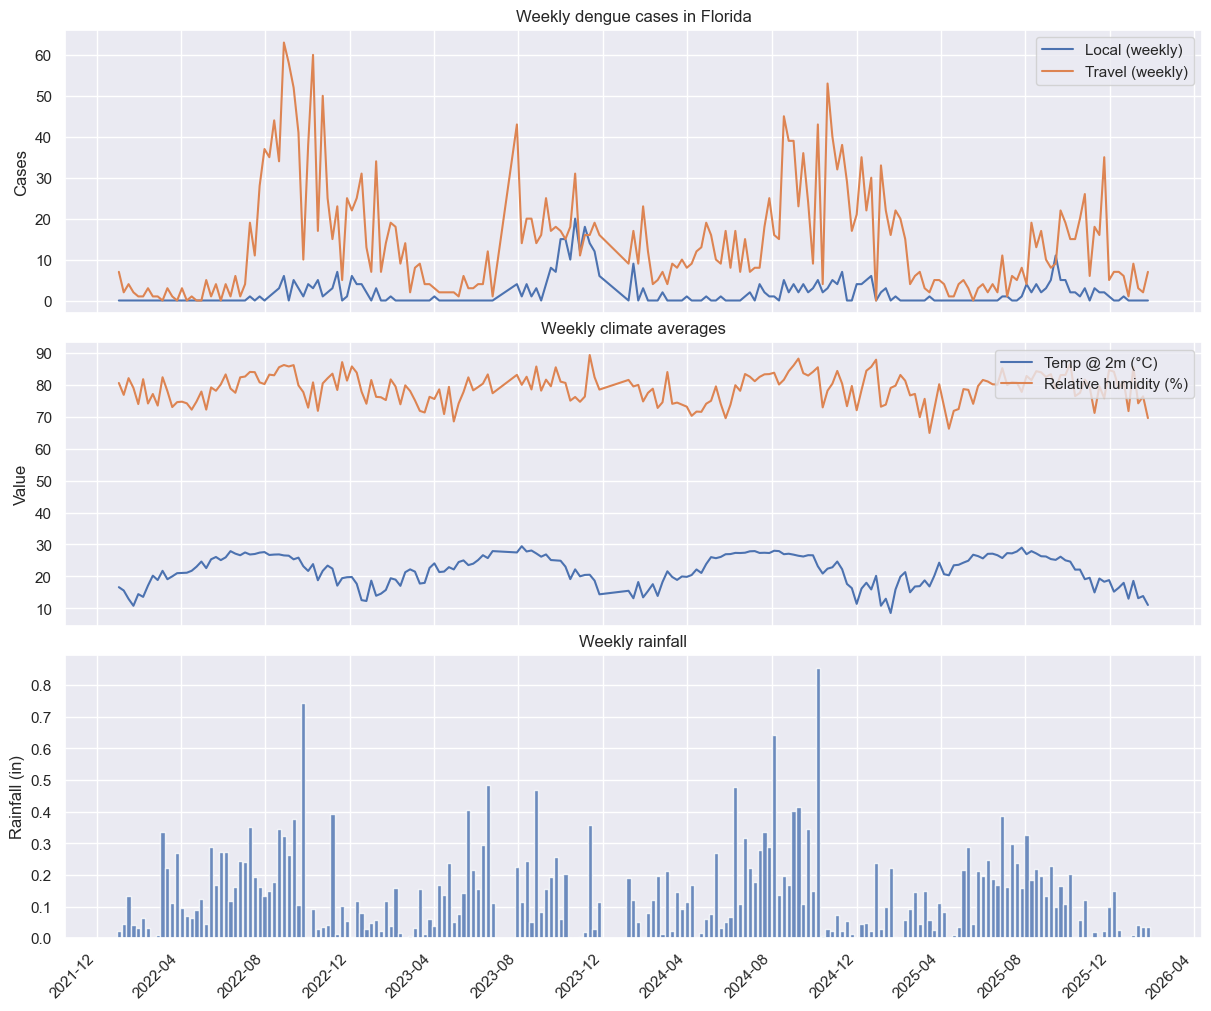

In [9]:
# Results — Time series: dengue incidence and climate variables over time
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_ts = df.dropna(subset=["week_start"]).copy()
df_ts = df_ts.sort_values("week_start")

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True, constrained_layout=True)

# Dengue time series
axes[0].plot(df_ts["week_start"], df_ts["weekly_local_cases"], label="Local (weekly)")
axes[0].plot(df_ts["week_start"], df_ts["weekly_travel_cases"], label="Travel (weekly)")
axes[0].set_title("Weekly dengue cases in Florida")
axes[0].set_ylabel("Cases")
axes[0].legend(loc="upper right")

# Climate time series (temperature and RH)
axes[1].plot(df_ts["week_start"], df_ts["Temp @ 2m (C) Avg (Weekly Avg)"], label="Temp @ 2m (°C)")
axes[1].plot(df_ts["week_start"], df_ts["Relative Humidity (%) Avg (Weekly Avg)"], label="Relative humidity (%)")
axes[1].set_title("Weekly climate averages")
axes[1].set_ylabel("Value")
axes[1].legend(loc="upper right")

# Rainfall time series
axes[2].bar(df_ts["week_start"], df_ts["Rainfall Amount (in) Sum (Weekly Avg)"], width=6, alpha=0.8)
axes[2].set_title("Weekly rainfall")
axes[2].set_ylabel("Rainfall (in)")

axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=4))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(axes[2].get_xticklabels(), rotation=45, ha="right")

plt.show()

### Time series patterns (visual inspection)

The time series plots provide context for later exploratory comparisons:

- Weekly **travel-associated cases** show sustained activity across years, consistent with repeated importation pressure.
- Weekly **local cases** appear more episodic, with a prominent concentration of higher weeks during fall 2023 (see peak week reported earlier).
- Climate variables vary seasonally as expected; in Florida, higher temperatures and humidity generally co-occur during summer–early fall, while rainfall is more irregular week-to-week.

These visuals are descriptive only; they help motivate the next two steps: (1) seasonal summaries by month, and (2) same-week correlations/scatterplots without lag assumptions.

,Local (mean),Travel (mean)
month_name,,
Jan,1.000000,12.227273
Feb,0.125000,7.625000
Mar,0.111111,5.000000
Apr,0.117647,4.588235
May,0.058824,5.058824
Jun,0.222222,6.111111
Jul,1.071429,15.785714
Aug,2.588235,24.823529
Sep,4.058824,25.058824


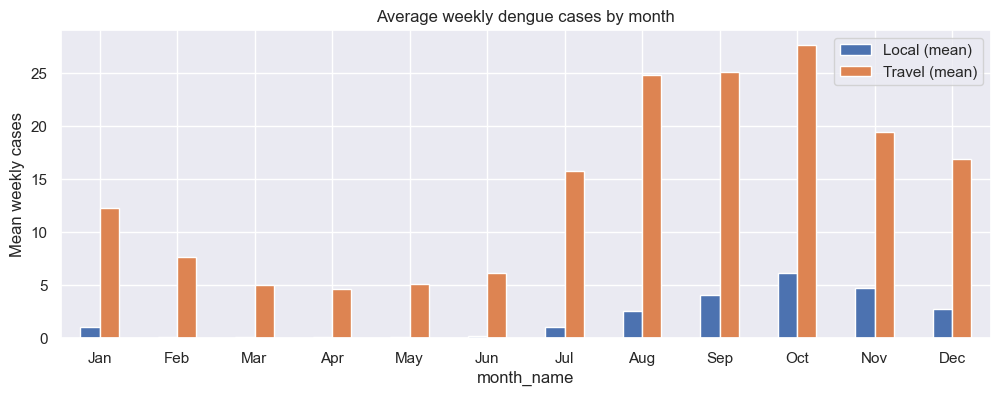

In [10]:
# Results — Seasonality: average dengue incidence by month
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_month = df.dropna(subset=["week_start"]).copy()
df_month["month_name"] = df_month["week_start"].dt.strftime("%b")

month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
month_avg = (
    df_month.groupby("month_name")[["weekly_local_cases", "weekly_travel_cases"]]
    .mean()
    .reindex(month_order)
    .rename(columns={"weekly_local_cases": "Local (mean)", "weekly_travel_cases": "Travel (mean)"})
 )

display(month_avg)

ax = month_avg.plot(kind="bar", figsize=(12, 4), rot=0)
ax.set_title("Average weekly dengue cases by month")
ax.set_ylabel("Mean weekly cases")
plt.show()

### Seasonal signal (month-of-year averages)

Averaging weekly incidence by month highlights the expected late-summer to fall seasonality described in the Introduction:

- In this dataset, mean weekly **local** case counts are highest in **October** (approximately $6.11$) and remain elevated into **November** (approximately $4.71$), with September also relatively high (approximately $4.06$).
- Travel-associated cases also show seasonal structure, consistent with both travel patterns and the broader regional dengue context.

This month-of-year summary is descriptive and does not distinguish between travel-driven and climate-driven mechanisms; it primarily clarifies *when* higher local transmission tends to occur in the weekly series.

,weekly_local_cases,weekly_travel_cases,Temp @ 60cm (C) Avg (Weekly Avg),Temp @ 2m (C) Avg (Weekly Avg),Temp @ 10m (C) Avg (Weekly Avg),Relative Humidity (%) Avg (Weekly Avg),Rainfall Amount (in) Sum (Weekly Avg)
weekly_local_cases,1.000,0.382,0.005,0.009,0.012,0.205,-0.017
weekly_travel_cases,0.382,1.000,0.103,0.110,0.109,0.334,0.085
Temp @ 60cm (C) Avg (Weekly Avg),0.005,0.103,1.000,1.000,0.999,0.380,0.457
Temp @ 2m (C) Avg (Weekly Avg),0.009,0.110,1.000,1.000,1.000,0.383,0.456
Temp @ 10m (C) Avg (Weekly Avg),0.012,0.109,0.999,1.000,1.000,0.379,0.449
Relative Humidity (%) Avg (Weekly Avg),0.205,0.334,0.380,0.383,0.379,1.000,0.510
Rainfall Amount (in) Sum (Weekly Avg),-0.017,0.085,0.457,0.456,0.449,0.510,1.000


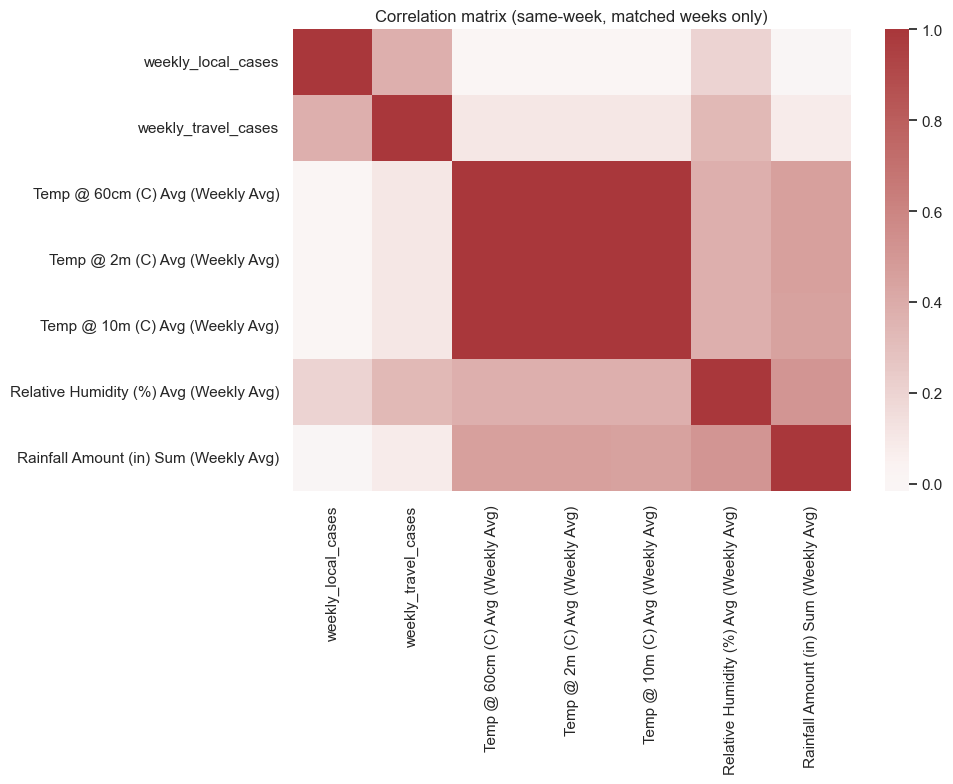

Same-week correlations with weekly_local_cases:
Relative Humidity (%) Avg (Weekly Avg)    0.205
Temp @ 10m (C) Avg (Weekly Avg)           0.012
Temp @ 2m (C) Avg (Weekly Avg)            0.009
Temp @ 60cm (C) Avg (Weekly Avg)          0.005
Rainfall Amount (in) Sum (Weekly Avg)    -0.017

Same-week correlations with weekly_travel_cases:
Relative Humidity (%) Avg (Weekly Avg)    0.334
Temp @ 2m (C) Avg (Weekly Avg)            0.110
Temp @ 10m (C) Avg (Weekly Avg)           0.109
Temp @ 60cm (C) Avg (Weekly Avg)          0.103
Rainfall Amount (in) Sum (Weekly Avg)     0.085


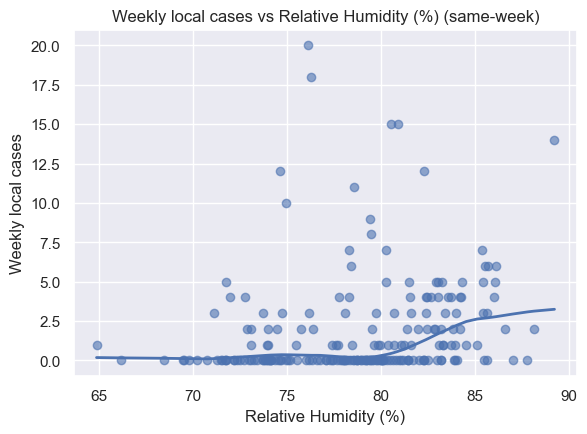

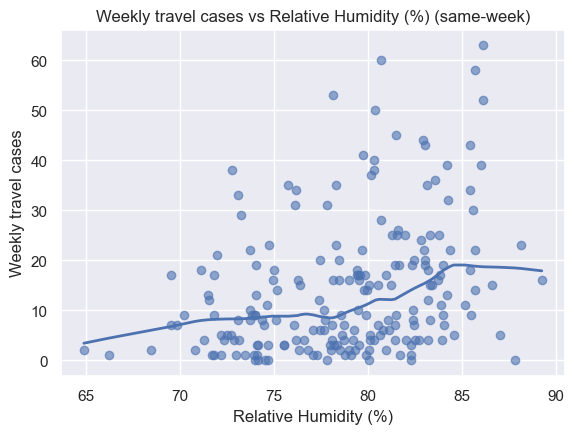

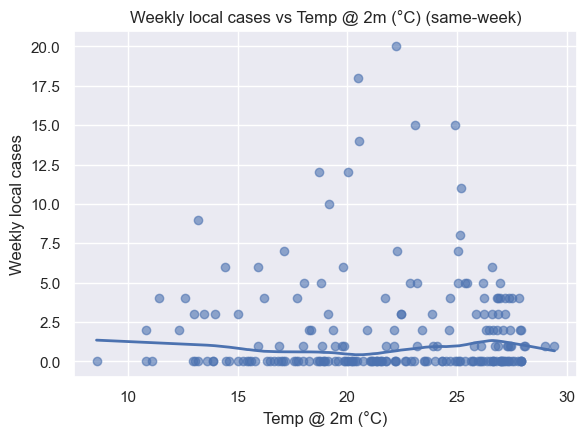

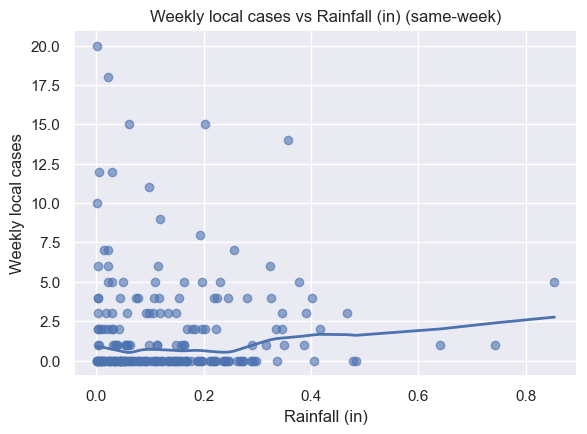

In [11]:
# Results — Same-week relationships: correlations + scatterplots (no lag assumptions)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess

sns.set_theme()

vars_for_corr = [
    "weekly_local_cases",
    "weekly_travel_cases",
    "Temp @ 60cm (C) Avg (Weekly Avg)",
    "Temp @ 2m (C) Avg (Weekly Avg)",
    "Temp @ 10m (C) Avg (Weekly Avg)",
    "Relative Humidity (%) Avg (Weekly Avg)",
    "Rainfall Amount (in) Sum (Weekly Avg)",
 ]

corr = df[vars_for_corr].corr(numeric_only=True)
display(corr.round(3))

plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=False, cmap="vlag", center=0)
plt.title("Correlation matrix (same-week, matched weeks only)")
plt.show()

# Correlations of outcomes vs climate variables (printed for easy reporting)
corr_local = corr.loc[climate_vars, "weekly_local_cases"].sort_values(ascending=False)
corr_travel = corr.loc[climate_vars, "weekly_travel_cases"].sort_values(ascending=False)

print("Same-week correlations with weekly_local_cases:")
print(corr_local.round(3).to_string())
print()
print("Same-week correlations with weekly_travel_cases:")
print(corr_travel.round(3).to_string())

# Scatterplots with LOWESS smoothing (exploratory)
def scatter_lowess(x: pd.Series, y: pd.Series, x_label: str, y_label: str, frac: float = 0.35):
    d = pd.DataFrame({"x": x, "y": y}).dropna()
    plt.figure(figsize=(6.5, 4.5))
    plt.scatter(d["x"], d["y"], alpha=0.6)
    if len(d) >= 10:
        sm = lowess(d["y"], d["x"], frac=frac, return_sorted=True)
        plt.plot(sm[:, 0], sm[:, 1], linewidth=2)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(f"{y_label} vs {x_label} (same-week)")
    plt.show()

scatter_lowess(df["Relative Humidity (%) Avg (Weekly Avg)"], df["weekly_local_cases"], "Relative Humidity (%)", "Weekly local cases")
scatter_lowess(df["Relative Humidity (%) Avg (Weekly Avg)"], df["weekly_travel_cases"], "Relative Humidity (%)", "Weekly travel cases")
scatter_lowess(df["Temp @ 2m (C) Avg (Weekly Avg)"], df["weekly_local_cases"], "Temp @ 2m (°C)", "Weekly local cases")
scatter_lowess(df["Rainfall Amount (in) Sum (Weekly Avg)"], df["weekly_local_cases"], "Rainfall (in)", "Weekly local cases")

### Same-week climate relationships (exploratory; no lag)

To align with the project scope, the analyses above examine **same-week** relationships only (no lagged climate variables). Key patterns in this dataset are modest:

- For **local cases**, the largest same-week correlation among the included climate variables is with **relative humidity** (approximately $r\approx0.205$). Rainfall is near zero (approximately $r\approx-0.017$), and temperatures are very small (approximately $r\approx0.005$ to $0.012$ depending on height).
- For **travel-associated cases**, correlations are generally stronger than local (as expected given larger counts and variability), with **relative humidity** again largest (approximately $r\approx0.334$), and small positive correlations with temperature (approximately $r\approx0.10$) and rainfall (approximately $r\approx0.085$).

The scatterplots (with LOWESS curves) should be interpreted as descriptive structure checks rather than evidence of a causal effect; later modeling (and especially any lagged analysis) would be needed to better separate seasonality, reporting dynamics, and mechanistic climatic drivers.